Reinhard Logik (Luma)

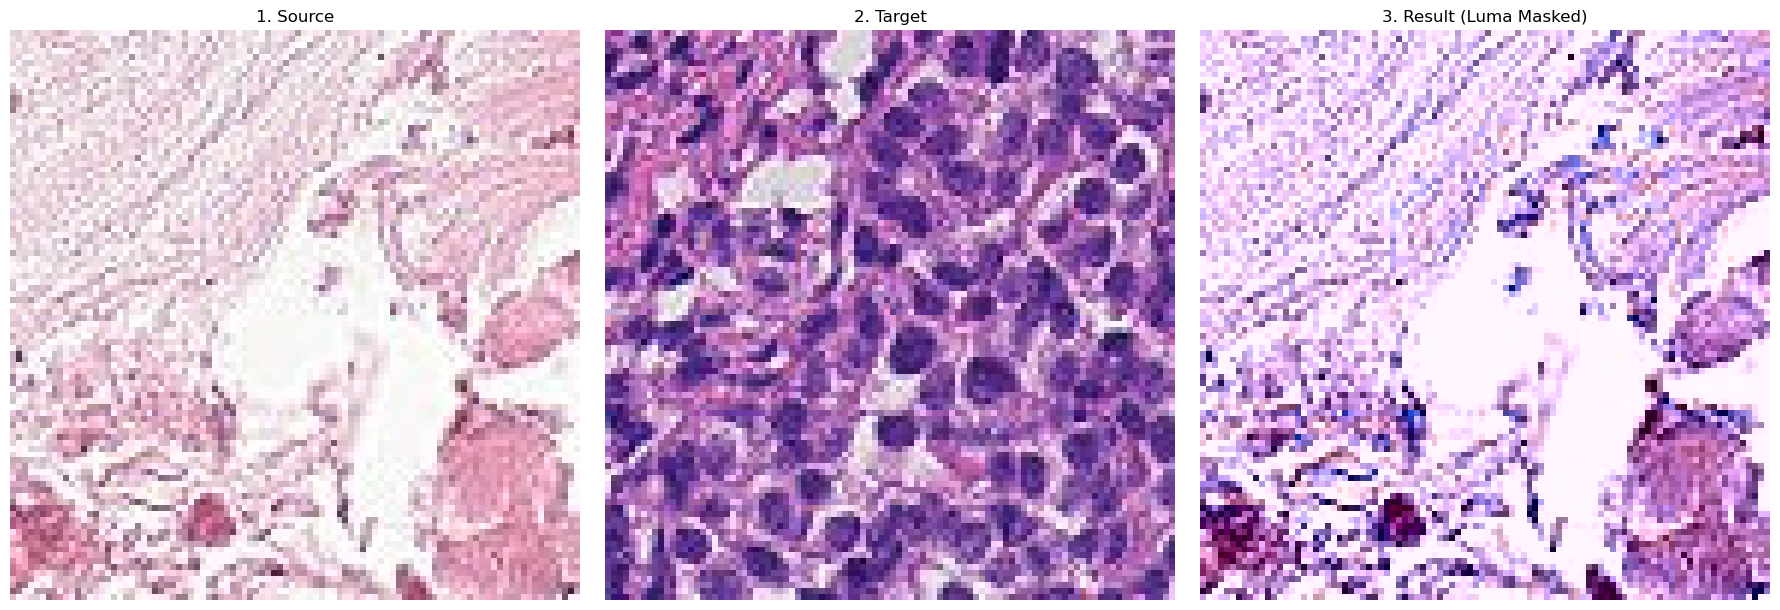

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. HILFSFUNKTIONEN ---
def bgr_to_rgb(img):
    """Konvertiert BGR (OpenCV) zu RGB (Matplotlib) für korrekte Farben im Plot."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def get_tissue_mask_manual(image, threshold_value=210):
    """Erstellt eine Maske basierend auf der Helligkeit (Luma-Key)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # THRESH_BINARY_INV: Alles was dunkler als 'threshold_value' ist, wird Weiß (Gewebe)
    _, mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)
    return mask

def get_mean_std_masked(image, mask=None):
    """Berechnet Mittelwert und Standardabweichung nur für das maskierte Gewebe."""
    mean, std = cv2.meanStdDev(image, mask=mask)
    return mean.flatten(), std.flatten()

# --- 2. DIE HAUPTFUNKTION ---
def normalize_stain_reinhard_custom(src_img, target_img, src_thresh=210, target_thresh=210):
    """Reinhard-Normalisierung mit manuell einstellbaren Luma-Masken."""
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Masken generieren
    src_mask = get_tissue_mask_manual(src_img, threshold_value=src_thresh)
    target_mask = get_tissue_mask_manual(target_img, threshold_value=target_thresh)

    # Statistiken anhand der Masken berechnen
    src_mean, src_std = get_mean_std_masked(src_lab, mask=src_mask)
    target_mean, target_std = get_mean_std_masked(target_lab, mask=target_mask)

    src_std[src_std == 0] = 1e-5 # Zero-Division-Schutz

    # Reinhard-Formel auf alle Kanäle anwenden
    l, a, b = cv2.split(src_lab)
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    # Zusammenfügen und zurückwandeln
    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    
    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)

# --- 3. AUSFÜHRUNG & VISUALISIERUNG ---
# Pfade (Bitte prüfen, ob sie für dein Setup stimmen)
src_path = '../data/raw/source.tif'
target_path = '../data/raw/target.tif'

if os.path.exists(src_path) and os.path.exists(target_path):
    src_img = cv2.imread(src_path)
    target_img = cv2.imread(target_path)

    # Hier kannst du die Thresholds anpassen!
    result_img = normalize_stain_reinhard_custom(src_img, target_img, src_thresh=200, target_thresh=230)

    # Plotten
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(bgr_to_rgb(src_img))
    axes[0].set_title('1. Source')
    axes[0].axis('off')
    
    axes[1].imshow(bgr_to_rgb(target_img))
    axes[1].set_title('2. Target')
    axes[1].axis('off')
    
    axes[2].imshow(bgr_to_rgb(result_img))
    axes[2].set_title('3. Result (Luma Masked)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Bilder nicht gefunden!")

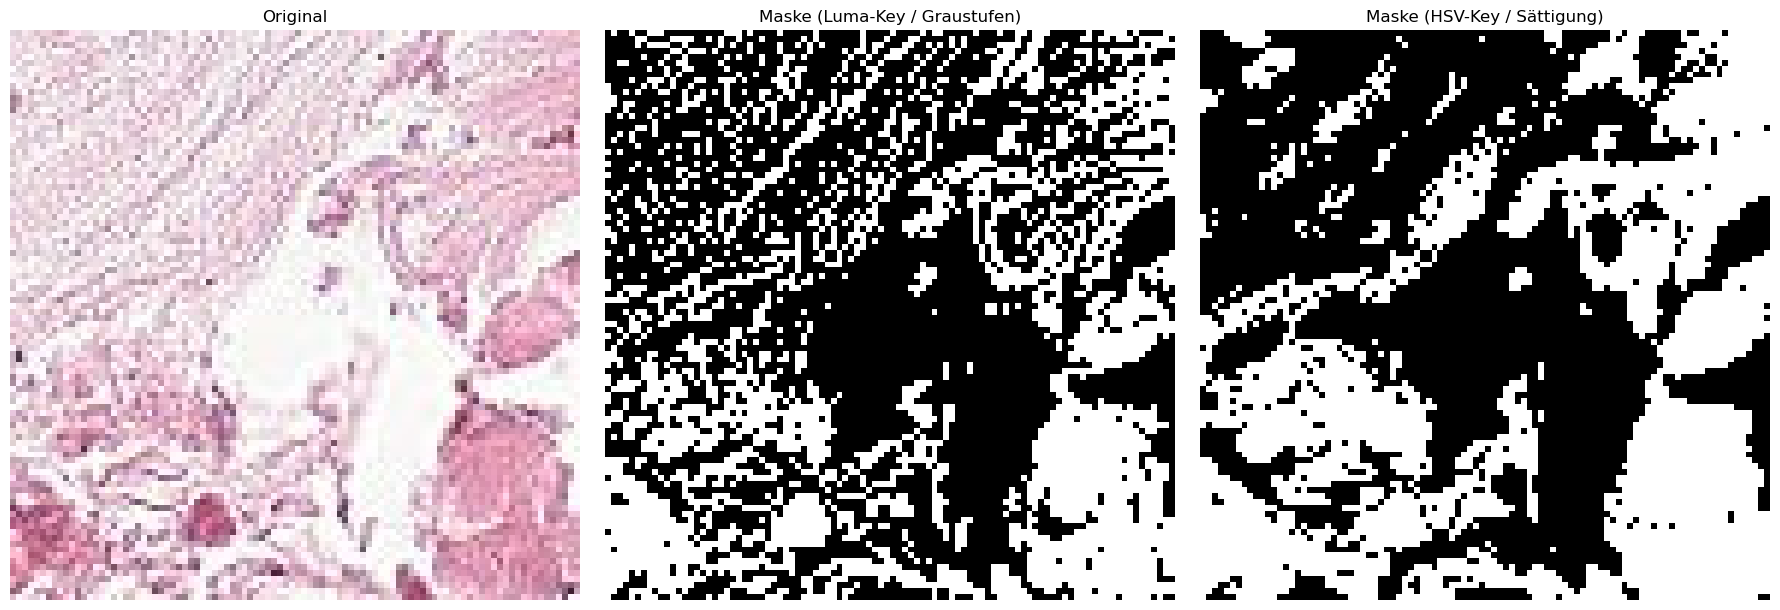

In [14]:
def get_tissue_mask_hsv(image, saturation_threshold=15):
    """
    Erstellt eine Maske basierend auf der Sättigung (Chroma-Key).
    Alles, was eine höhere Sättigung als 'saturation_threshold' hat, wird als Gewebe erkannt.
    """
    # 1. Bild in den HSV-Farbraum umwandeln (Hue, Saturation, Value)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # 2. Den Sättigungs-Kanal (Index 1) extrahieren
    s_channel = hsv[:, :, 1]
    
    # 3. Normaler Threshold: Wenn Sättigung > saturation_threshold, dann Weiß (255)
    _, mask = cv2.threshold(s_channel, saturation_threshold, 255, cv2.THRESH_BINARY)
    
    return mask

# --- Test und Vergleich: Luma vs. HSV ---
# Wir nutzen das src_img von oben
mask_luma = get_tissue_mask_manual(src_img, threshold_value=210)
mask_hsv = get_tissue_mask_hsv(src_img, saturation_threshold=25) # 15 ist oft ein sehr guter Startwert für H&E

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(bgr_to_rgb(src_img))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(mask_luma, cmap='gray')
axes[1].set_title('Maske (Luma-Key / Graustufen)')
axes[1].axis('off')

axes[2].imshow(mask_hsv, cmap='gray')
axes[2].set_title('Maske (HSV-Key / Sättigung)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

HSV Maske

✅ Datei gefunden: ../data/raw/source.tif
✅ Datei gefunden: ../data/raw/target.tif


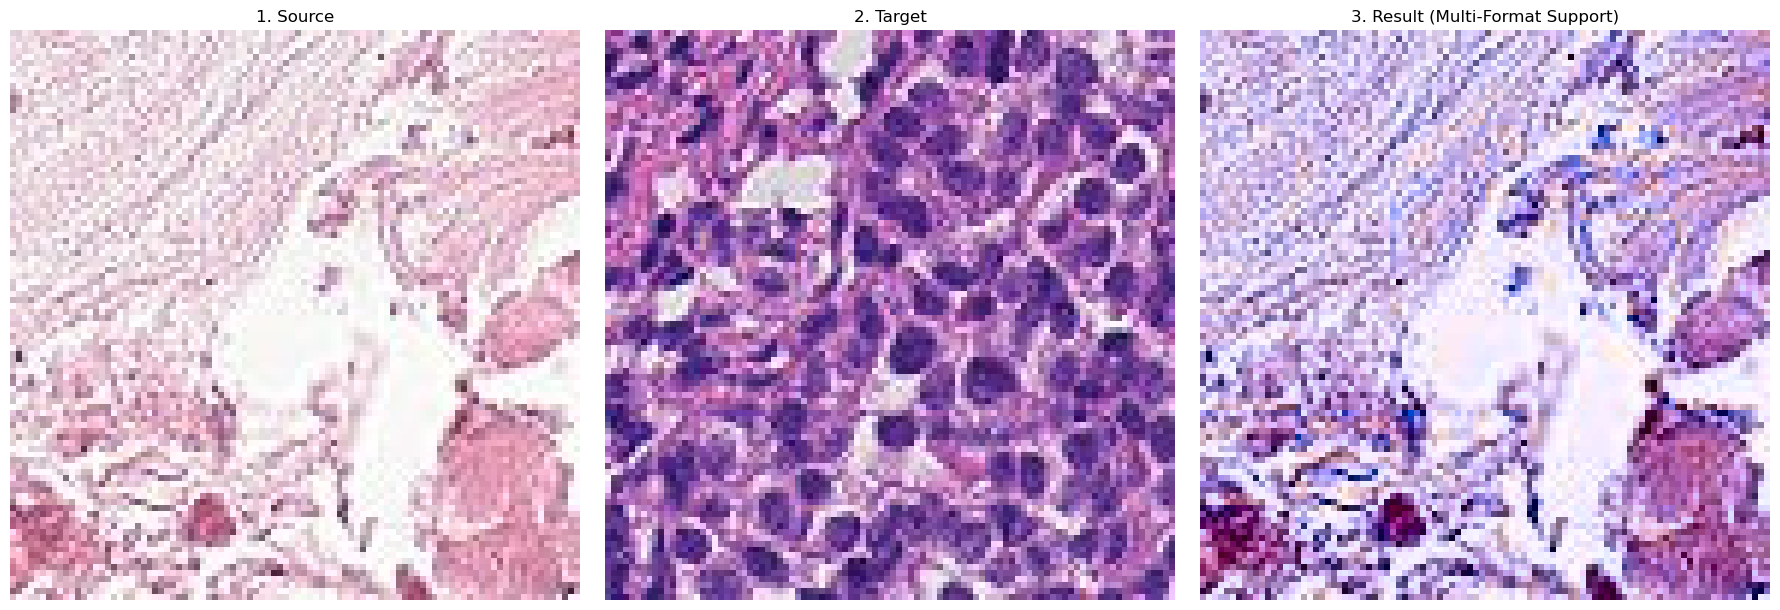

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Notebook Magic Command für inline Plots
%matplotlib inline

# --- 1. HILFSFUNKTIONEN (Schnittplatz-Werkzeuge) ---
def bgr_to_rgb(img):
    """Konvertiert BGR zu RGB für korrekte Farben im Plot."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def get_tissue_mask_hsv(image, saturation_threshold=15):
    """
    Erstellt eine Gewebe-Maske basierend auf der Sättigung (HSV Chroma-Key).
    Alles mit Sättigung > saturation_threshold wird als Gewebe erkannt.
    """
    # In HSV wandeln
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Sättigungs-Kanal extrahieren
    s_channel = hsv[:, :, 1]
    # Thresholding: Sättigung > x -> Weiß (Gewebe)
    _, mask = cv2.threshold(s_channel, saturation_threshold, 255, cv2.THRESH_BINARY)
    return mask

def get_mean_std_masked(image, mask=None):
    """Berechnet Mean/Std nur für maskierte Pixel."""
    mean, std = cv2.meanStdDev(image, mask=mask)
    return mean.flatten(), std.flatten()


# --- 2. DIE HAUPTFUNKTION (Das eigentliche Grading) ---
def normalize_stain_reinhard_hsv_final(src_img, target_img, src_sat_thresh=15, target_sat_thresh=15):
    """
    Führt die Reinhard-Normalisierung durch, wobei die Farbstatisitken
    exklusiv mittels HSV-Sättigungs-Masken berechnet werden.
    Gibt das finale BGR-Echtfarben-Bild zurück.
    """
    # 1. LAB Konvertierung (float32 für Berechnung)
    src_lab = cv2.cvtColor(src_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    target_lab = cv2.cvtColor(target_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # 2. HSV-Sättigungs-Masken generieren (Die Keys erstellen)
    src_mask = get_tissue_mask_hsv(src_img, saturation_threshold=src_sat_thresh)
    target_mask = get_tissue_mask_hsv(target_img, saturation_threshold=target_sat_thresh)

    # 3. Statistiken NUR für das maskierte Gewebe berechnen (Lese die Scopes)
    src_mean, src_std = get_mean_std_masked(src_lab, mask=src_mask)
    target_mean, target_std = get_mean_std_masked(target_lab, mask=target_mask)

    # Zero-Division Schutz
    src_std[src_std == 0] = 1e-5

    # 4. Reinhard-Formel auf alle Kanäle anwenden (Das Color-Transfer)
    l, a, b = cv2.split(src_lab)
    
    # Formel: Inorm = (Isrc - µsrc) * (σtrg / σsrc) + µtrg
    l_norm = (l - src_mean[0]) * (target_std[0] / src_std[0]) + target_mean[0]
    a_norm = (a - src_mean[1]) * (target_std[1] / src_std[1]) + target_mean[1]
    b_norm = (b - src_mean[2]) * (target_std[2] / src_std[2]) + target_mean[2]

    # 5. Zusammenfügen, Clipping und zurück zu BGR (Render den Fill-Layer)
    result_lab = cv2.merge((l_norm, a_norm, b_norm))
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)
    
    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2BGR)


# --- 3. AUSFÜHRUNG & VISUALISIERUNG (Der finale Kontroll-Monitor) ---
# --- NEU: Der intelligente Media-Relinker ---
def find_and_load_image(directory, base_name):
    """
    Sucht in einem Verzeichnis nach einem Bild mit dem angegebenen Basis-Namen
    und probiert verschiedene gängige Formate durch.
    Ignoriert Groß-/Kleinschreibung bei Dateiendungen (z.B. .JPG vs .jpg).
    """
    # Unsere erlaubten Formate
    valid_extensions = ['.jpg', '.jpeg', '.png', '.tif', '.tiff']
    
    # Alle Dateien im Zielordner auflisten
    if not os.path.exists(directory):
        print(f"❌ Fehler: Das Verzeichnis {directory} existiert nicht.")
        return None

    files_in_dir = os.listdir(directory)
    
    for file in files_in_dir:
        # Dateinamen und Endung trennen (z.B. "source" und ".png")
        name, ext = os.path.splitext(file)
        
        # Wenn der Name passt und die Endung (kleingeschrieben) in unserer Liste ist
        if name == base_name and ext.lower() in valid_extensions:
            full_path = os.path.join(directory, file)
            print(f"✅ Datei gefunden: {full_path}")
            return cv2.imread(full_path)
            
    print(f"❌ Fehler: Kein Bild für '{base_name}' mit passendem Format in {directory} gefunden.")
    return None

# ==========================================
# 3. AUSFÜHRUNG & VISUALISIERUNG (Dynamisch)
# ==========================================

data_dir = '../data/raw'

# Wir übergeben nur noch den Ordner und den Dateinamen OHNE Endung!
src_img = find_and_load_image(data_dir, 'source')
target_img = find_and_load_image(data_dir, 'target')

if src_img is not None and target_img is not None:
    
    # Die Normalisierung durchführen (HSV-Methode)
    result_img = normalize_stain_reinhard_hsv_final(src_img, target_img, src_sat_thresh=35, target_sat_thresh=15)

    # Visualisierung des FINALEN Farbbildes
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(bgr_to_rgb(src_img))
    axes[0].set_title('1. Source')
    axes[0].axis('off')
    
    axes[1].imshow(bgr_to_rgb(target_img))
    axes[1].set_title('2. Target')
    axes[1].axis('off')
    
    axes[2].imshow(bgr_to_rgb(result_img))
    axes[2].set_title('3. Result (Multi-Format Support)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

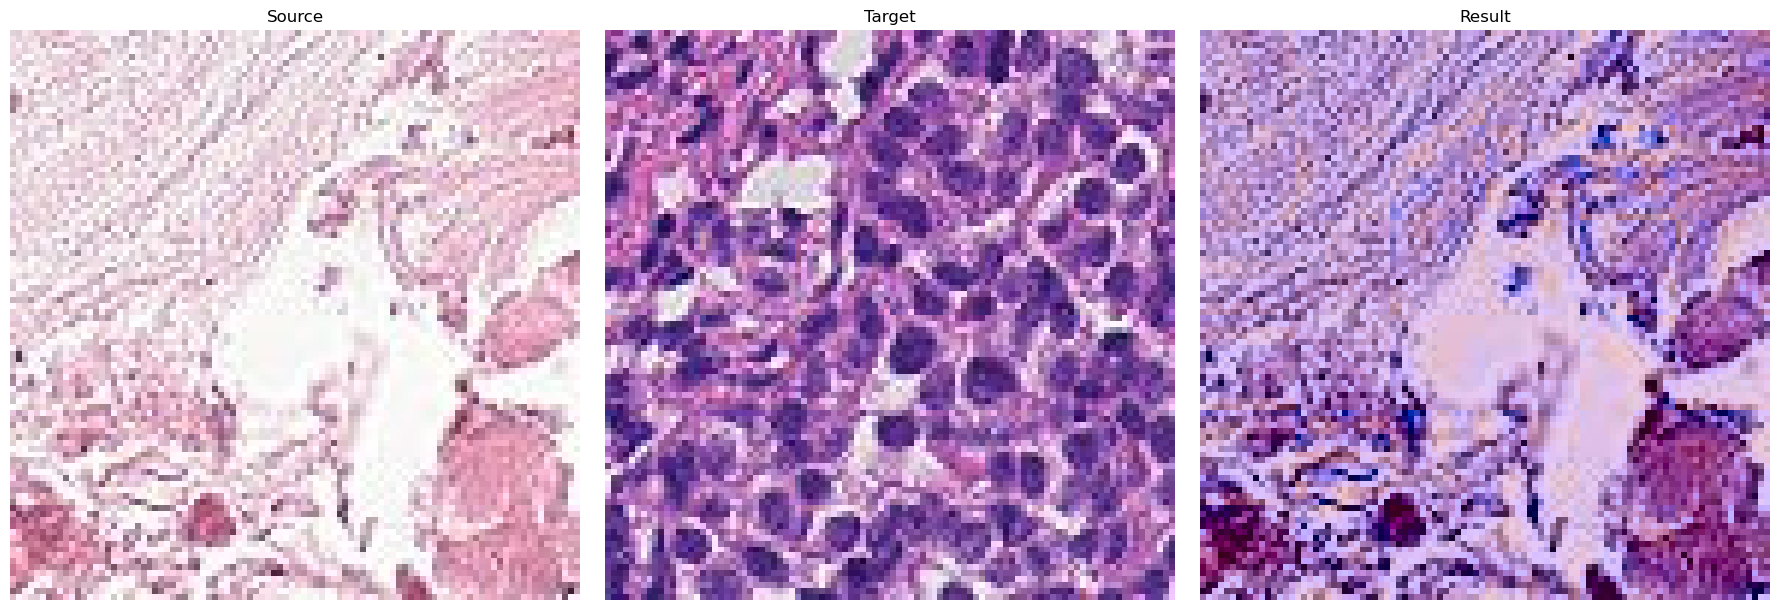

In [26]:
import sys
import os
import cv2
import matplotlib.pyplot as plt

# 1. Dem Notebook sagen, wo der src-Ordner liegt (einen Ordner nach oben)
sys.path.append(os.path.abspath('..'))

# 2. DEIN EIGENES MODUL IMPORTIEREN!
from src.reinhard import normalize_stain_reinhard_hsv_final

# 3. Hilfsfunktionen fürs Notebook
def bgr_to_rgb(img): return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
def find_and_load_image(directory, base_name):
    valid_extensions = ['.jpg', '.jpeg', '.png', '.tif', '.tiff']
    if not os.path.exists(directory): return None
    for file in os.listdir(directory):
        name, ext = os.path.splitext(file)
        if name == base_name and ext.lower() in valid_extensions:
            return cv2.imread(os.path.join(directory, file))
    return None

# 4. Ausführung
data_dir = '../data/raw'
src_img = find_and_load_image(data_dir, 'source')
target_img = find_and_load_image(data_dir, 'target')

if src_img is not None and target_img is not None:
    # Hier rufst du jetzt deinen sauberen Code aus der src/reinhard.py auf!
    result_img = normalize_stain_reinhard_hsv_final(src_img, target_img)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(bgr_to_rgb(src_img)); axes[0].set_title('Source'); axes[0].axis('off')
    axes[1].imshow(bgr_to_rgb(target_img)); axes[1].set_title('Target'); axes[1].axis('off')
    axes[2].imshow(bgr_to_rgb(result_img)); axes[2].set_title('Result'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()